In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
clean_data = pd.read_csv("../data/processed/clean_data.csv")
print(clean_data.shape)
clean_data.head(10)

(259092, 12)


,brand,model,vehicleType,power,gearbox,kilometer,fuelType,yearOfRegistration,seller,dataSource,price,price_tier
0,audi,a4,coupe,190.0,manual,125000.0,diesel,2011,private,kaggle,26931.044776,luxury
1,jeep,grand,suv,163.0,automatic,125000.0,diesel,2004,private,kaggle,14422.089552,mid-range
2,volkswagen,golf,compact,75.0,manual,150000.0,gasoline,2001,private,kaggle,2207.462687,budget
3,skoda,fabia,compact,69.0,manual,90000.0,diesel,2008,private,kaggle,5297.910448,mid-range
4,bmw,3-series,sedan,102.0,manual,150000.0,gasoline,1995,private,kaggle,956.567164,budget
5,peugeot,2-reihe,convertible,109.0,manual,150000.0,gasoline,2004,private,kaggle,3237.611940,budget
6,ford,c-max,van,125.0,manual,30000.0,gasoline,2014,private,kaggle,21338.805970,luxury
7,volkswagen,golf,compact,101.0,manual,150000.0,gasoline,1998,private,kaggle,1470.170149,budget
8,mazda,3-reihe,sedan,105.0,manual,150000.0,gasoline,2004,private,kaggle,2943.283582,budget
9,volkswagen,passat,station-wagon,140.0,manual,150000.0,diesel,2005,private,kaggle,4119.125373,budget


In [3]:
clean_data['kilometer'].describe()

count    259092.000000
mean     122871.117537
std       40816.897252
min           0.000000
25%      100000.000000
50%      150000.000000
75%      150000.000000
max      225000.000000
Name: kilometer, dtype: float64

In [4]:
clean_data['power'].describe()

count    259092.000000
mean        127.099096
std          52.851937
min           5.000000
25%          87.000000
50%         116.000000
75%         159.000000
max         252.000000
Name: power, dtype: float64

In [5]:
clean_data['yearOfRegistration'].describe()

count    259092.000000
mean       2004.182271
std           7.331479
min        1910.000000
25%        2000.000000
50%        2004.000000
75%        2009.000000
max        2023.000000
Name: yearOfRegistration, dtype: float64

In [6]:
clean_data['price'].describe()

count    2.590920e+05
mean     1.021094e+04
std      1.921137e+04
min      5.003582e+02
25%      2.428209e+03
50%      5.739403e+03
75%      1.280328e+04
max      1.839552e+06
Name: price, dtype: float64

In [31]:
clean_data['brand'].unique()

<StringArray>
[         'audi',          'jeep',    'volkswagen',         'skoda',
           'bmw',       'peugeot',          'ford',         'mazda',
        'nissan',       'renault', 'mercedes-benz',          'opel',
       'citroen',         'honda',          'fiat',          'mini',
         'smart',       'hyundai',          'seat',        'subaru',
         'volvo',    'mitsubishi',    'alfa-romeo',           'kia',
        'suzuki',        'lancia',       'porsche',        'toyota',
     'chevrolet',         'dacia',      'daihatsu',      'chrysler',
        'jaguar',        'daewoo',         'rover',          'saab',
    'land-rover',       'trabant',          'lada',         'cupra',
            'mg',            'ds',           'byd',       'ferrari',
         'dodge',            'dr',         'tesla',       'bentley',
   'lamborghini',     'leapmotor',         'omoda',           'evo',
         'micro',          'togg',           'xev',           'kgm',
       'lynk-co',   

In [32]:
clean_data['model'].unique()

<StringArray>
[           'a4',         'grand',          'golf',         'fabia',
      '3-series',       '2-reihe',         'c-max',       '3-reihe',
        'passat',        'navara',
 ...
           'x7m',          'evo5',          'g500',        'eqe300',
         'nv200',        'e-golf',     'onecabrio',         'ioniq',
 'cooperclubman',        'cle200']
Length: 717, dtype: str

In [33]:
clean_data['vehicleType'].unique()

<StringArray>
[        'coupe',           'suv',       'compact',         'sedan',
   'convertible',           'van', 'station-wagon',         'other']
Length: 8, dtype: str

In [34]:
clean_data['fuelType'].unique()

<StringArray>
['diesel', 'gasoline', 'lpg', 'other', 'hybrid', 'cng', 'electric']
Length: 7, dtype: str

In [35]:
clean_data['price_reference_year'].unique()

array([2016., 2025.])

In [36]:
clean_data['gearbox'].unique()

<StringArray>
['manual', 'automatic', 'semi-automatic']
Length: 3, dtype: str

In [37]:
clean_data['seller'].unique()

<StringArray>
['private', 'dealer']
Length: 2, dtype: str

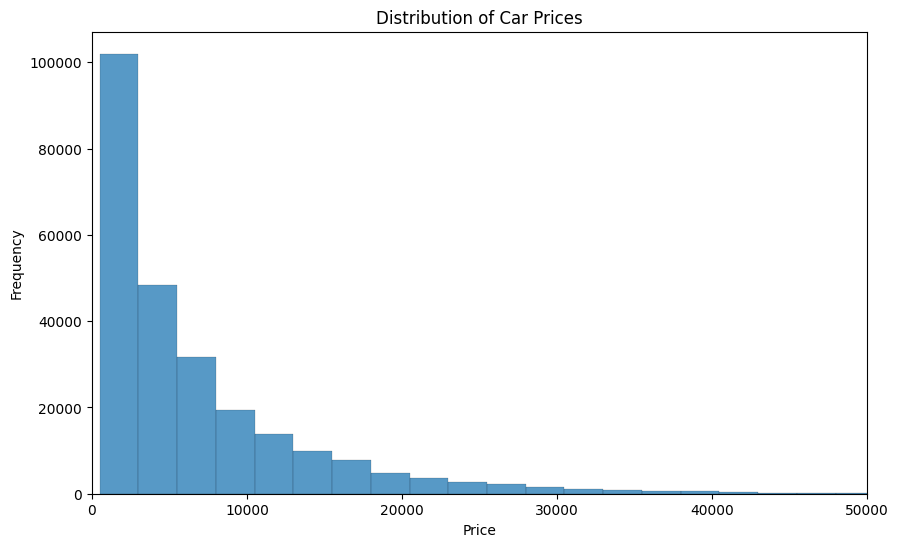

In [38]:
#plot the distribution of the price column
plt.figure(figsize=(10, 6))
sns.histplot(clean_data['price'], bins=500)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 50000)
plt.show()

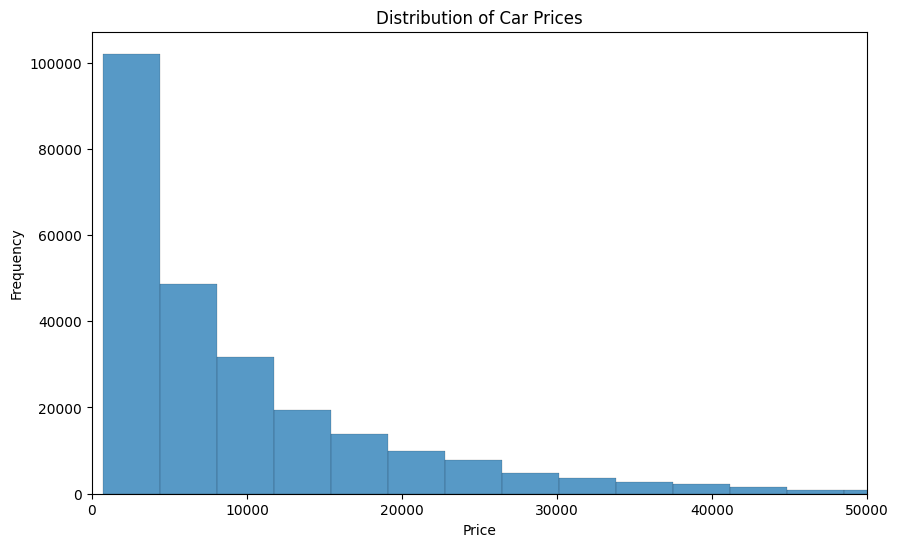

In [46]:
#plot the distribution of the price column
plt.figure(figsize=(10, 6))
sns.histplot(clean_data['normalized_price'], bins=500)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 50000)
plt.show()

In [39]:
# DATA TRANSFORMATION SECTION

CPI_USED_CARS: dict[int, float] = {
    2016: 100.5,
    2025: 147.1,
    2026: 147.9,
}
REFERENCE_YEAR: int = 2026


def normalize_price(price: float, source_year: int) -> float:
    if source_year not in CPI_USED_CARS:
        raise ValueError(
            f"No CPI entry for year {source_year}."
        )
    return price * (CPI_USED_CARS[REFERENCE_YEAR] / CPI_USED_CARS[source_year])

clean_data['normalized_price'] = clean_data.apply(
    lambda row: normalize_price(row['price'], row['price_reference_year']),
    axis=1
)

In [40]:
#create price tiers based on the price column
def price_tier(price):
    if price < 5000:
        return 'budget'
    elif price < 15000:
        return 'mid-range'
    else:
        return 'premium'
clean_data['price_tier1'] = clean_data['normalized_price'].apply(price_tier)
clean_data['price_tier1'].value_counts()

price_tier1
budget       111456
mid-range     89331
premium       52989
Name: count, dtype: int64

In [41]:
#create price tiers based on the price column
clean_data['price_tier2'] = clean_data['price'].apply(price_tier)
clean_data['price_tier2'].value_counts()

price_tier2
budget       144982
mid-range     79070
premium       29724
Name: count, dtype: int64

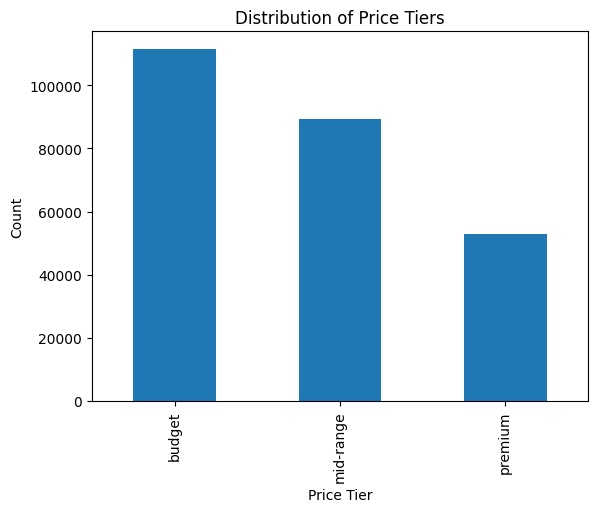

In [42]:
clean_data['price_tier1'].value_counts().plot(kind='bar')
plt.title('Distribution of Price Tiers')
plt.xlabel('Price Tier')
plt.ylabel('Count')
plt.show()

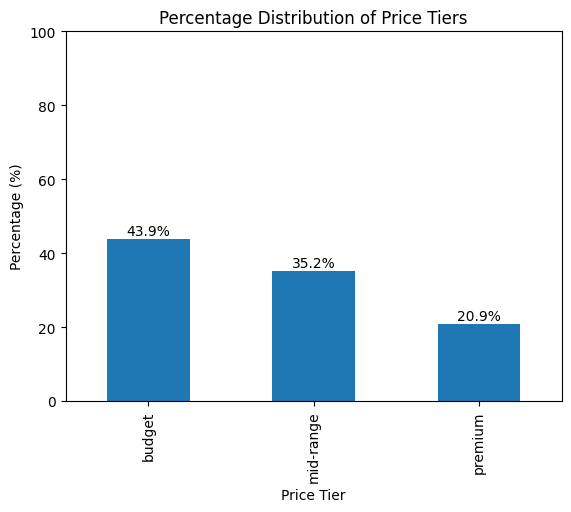

In [43]:
# plot percentage of price tiers
price_tier_counts = clean_data['price_tier1'].value_counts(normalize=True) * 100
price_tier_counts.plot(kind='bar')
plt.title('Percentage Distribution of Price Tiers')
plt.xlabel('Price Tier')
plt.ylabel('Percentage (%)')
# write percentage values on top of bars
for index, value in enumerate(price_tier_counts):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')
plt.ylim(0, 100)
plt.show()

In [44]:
merged_data = pd.read_csv("../data/interim/merged_data.csv")
print(merged_data.shape)
merged_data.head(10)

(374035, 12)


,brand,model,vehicleType,power,gearbox,kilometer,fuelType,yearOfRegistration,seller,dataSource,price_reference_year,price
0,volkswagen,golf,NaN,0.0,manuell,150000.0,benzin,1993.0,privat,kaggle,2016.0,480
1,audi,NaN,coupe,190.0,manuell,125000.0,diesel,2011.0,privat,kaggle,2016.0,18300
2,jeep,grand,suv,163.0,automatik,125000.0,diesel,2004.0,privat,kaggle,2016.0,9800
3,volkswagen,golf,kleinwagen,75.0,manuell,150000.0,benzin,2001.0,privat,kaggle,2016.0,1500
4,skoda,fabia,kleinwagen,69.0,manuell,90000.0,diesel,2008.0,privat,kaggle,2016.0,3600
5,bmw,3er,limousine,102.0,manuell,150000.0,benzin,1995.0,privat,kaggle,2016.0,650
6,peugeot,2_reihe,cabrio,109.0,manuell,150000.0,benzin,2004.0,privat,kaggle,2016.0,2200
7,volkswagen,andere,limousine,50.0,manuell,40000.0,benzin,1980.0,privat,kaggle,2016.0,0
8,ford,c_max,bus,125.0,manuell,30000.0,benzin,2014.0,privat,kaggle,2016.0,14500
9,volkswagen,golf,kleinwagen,101.0,manuell,150000.0,NaN,1998.0,privat,kaggle,2016.0,999


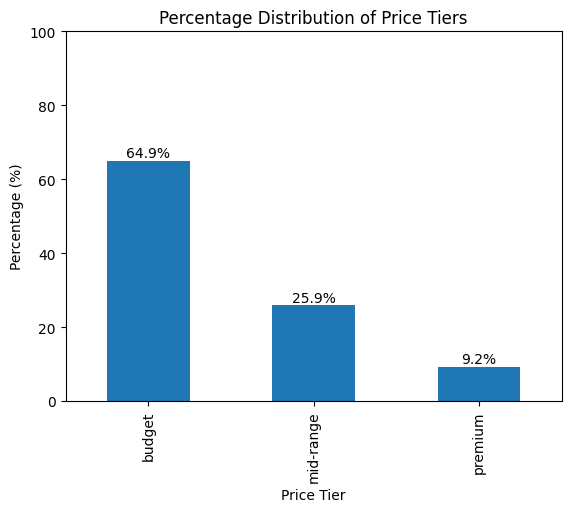

In [45]:
# plot the distribution of the price column for each price tier
merged_data['price_tier'] = merged_data['price'].apply(price_tier)
# plot percentage of price tiers
price_tier_counts = merged_data['price_tier'].value_counts(normalize=True) * 100
price_tier_counts.plot(kind='bar')
plt.title('Percentage Distribution of Price Tiers')
plt.xlabel('Price Tier')
plt.ylabel('Percentage (%)')
# write percentage values on top of bars
for index, value in enumerate(price_tier_counts):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')
plt.ylim(0, 100)
plt.show()